# Pasajeros de Avion

## Contexto:

El dataset AirPassengers contiene el registro mensual del total de pasajeros internacionales de aerolíneas (en miles) desde enero de 1949 hasta diciembre de 1960, abarcando 144 observaciones a lo largo de 12 años. Fue recopilado por Box & Jenkins y publicado en su libro clásico "Time Series Analysis: Forecasting and Control" (1970), convirtiéndose en el benchmark más usado para modelos de series temporales. Los valores oscilan aproximadamente entre 104,000 y 622,000 pasajeros, mostrando dos patrones muy claros: una tendencia creciente sostenida año tras año (reflejo del auge de la aviación comercial en los 50s) y una estacionalidad anual marcada, con picos en los meses de verano (julio–agosto) y valles en invierno, lo que lo hace ideal para practicar tanto ARIMA como SARIMA, ya que combina los dos componentes que estos modelos buscan capturar.


In [7]:
# Librerias necesarias

# Datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wbgapi as wb

# Modelos de tiempo
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

# Estadisticos
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.metrics import r2_score
from statsmodels.tsa.seasonal import seasonal_decompose

import warnings
warnings.filterwarnings('ignore')


In [3]:
# Cargar el dataset AirPassengers
data = sm.datasets.get_rdataset("AirPassengers", "datasets").data
data.head()

,time,value
0,1949.000000,112
1,1949.083333,118
2,1949.166667,132
3,1949.250000,129
4,1949.333333,121


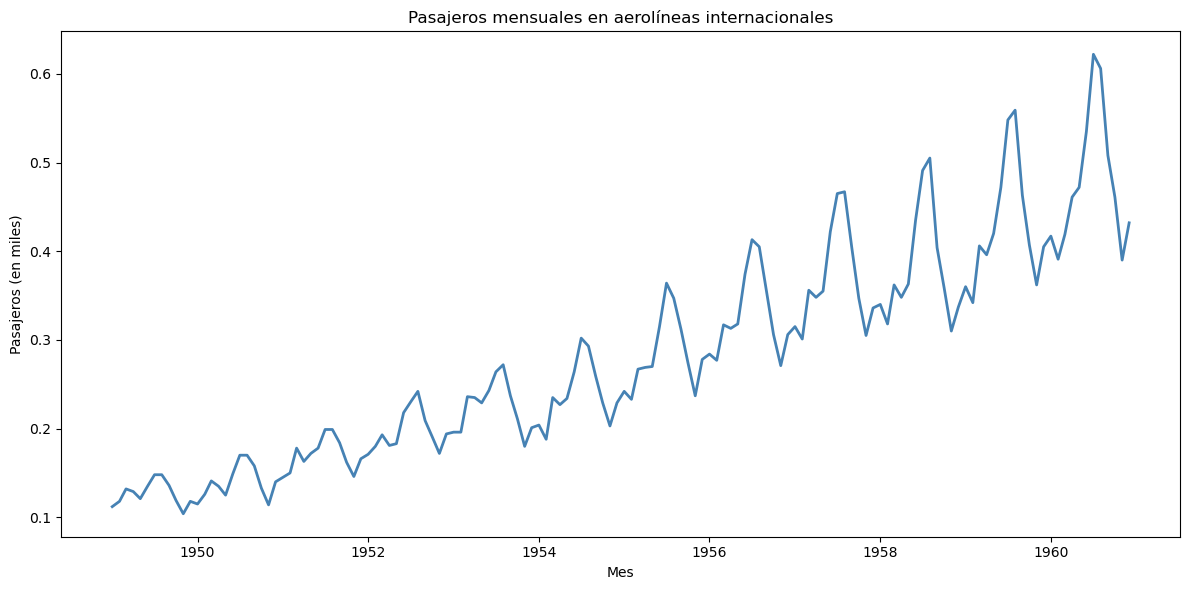

In [5]:
# 1. Cargar el dataset
data = sm.datasets.get_rdataset("AirPassengers", "datasets").data

# 2. Renombrar columnas
data = data.rename(columns={"time": "ds", "value": "y"})

# 3. Construir fechas reales
data["ds"] = pd.date_range(start="1949-01", periods=len(data), freq="MS")

# 4. Escalar valores a miles
data["y"] = data["y"] / 1e3

# 5. Indexar por fecha y normalizar al primer día del mes
data = data.set_index("ds")
data.index = pd.DatetimeIndex(data.index).to_period("M").to_timestamp()

# 6. Extraer la serie temporal
serie_airpassengers = data["y"]

# 7. Graficar
plt.figure(figsize=(12, 6))
plt.plot(serie_airpassengers.index, serie_airpassengers, color='steelblue', linewidth=2)
plt.xlabel('Mes')
plt.ylabel('Pasajeros (en miles)')
plt.title('Pasajeros mensuales en aerolíneas internacionales')
plt.tight_layout()
plt.show()


📈 Tendencia Alcista: La serie muestra un crecimiento promedio constante a largo plazo. Estadísticamente, esto significa que la media de los datos aumenta con el tiempo, por lo que la serie es no estacionaria.
🗓️ Estacionalidad Marcada: Se repiten patrones cíclicos cada 12 meses. Los picos (máximos) y valles (mínimos) ocurren en los mismos periodos cada año, lo que sugiere una fuerte dependencia de factores estacionales como las vacaciones de verano.
↕️ Efecto Multiplicativo: A medida que la tendencia sube, la magnitud de las oscilaciones también aumenta. Esto indica que la varianza no es constante (heterocedasticidad), lo que suele requerir una transformación (como aplicar logaritmos) para estabilizar los datos.
🔗 Autocorrelación: Los puntos no son independientes entre sí; el valor de un mes está fuertemente relacionado con el mes anterior y con el mismo mes del año pasado. Es la base para construir modelos predictivos tipo SARIMA.

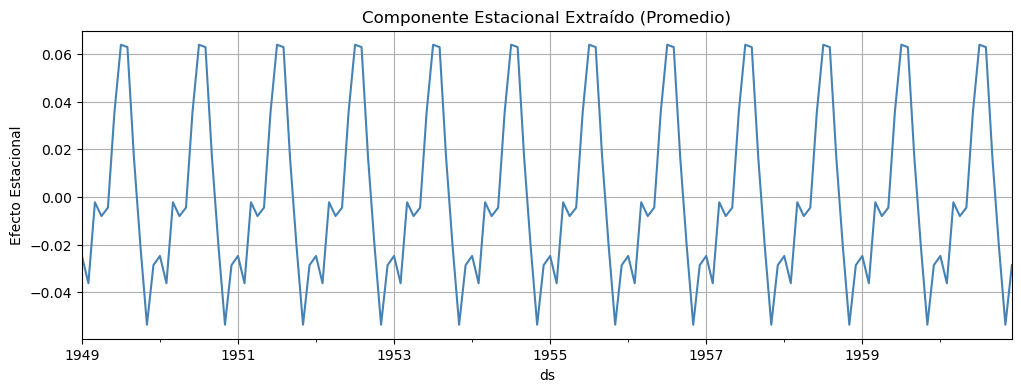

In [8]:
# 8. Descomposición aditiva
descomposicion = seasonal_decompose(serie_airpassengers, model='additive')

# 9. Graficar solo el componente estacional
plt.figure(figsize=(12, 4))
descomposicion.seasonal.plot(color='steelblue')
plt.title('Componente Estacional Extraído (Promedio)')
plt.ylabel('Efecto Estacional')
plt.grid(True)
plt.show()

🔄 Periodicidad Determinística: La gráfica muestra un ciclo que se repite de forma idéntica cada 12 unidades de tiempo. Esto confirma que el fenómeno tiene una frecuencia anual perfecta, eliminando cualquier ruido aleatorio para aislar el patrón.
⚖️ Media Cero: Al ser un componente extraído, la suma de los efectos dentro de un ciclo tiende a cero. Los valores positivos indican meses "por encima de la tendencia" (temporada alta) y los negativos meses "por debajo" (temporada baja).
📉 Identificación de Valores Críticos: Permite localizar con precisión los puntos de inflexión. El pico máximo anual representa el momento de mayor demanda, mientras que el valle más profundo señala el punto de estancamiento estacional recurrente.

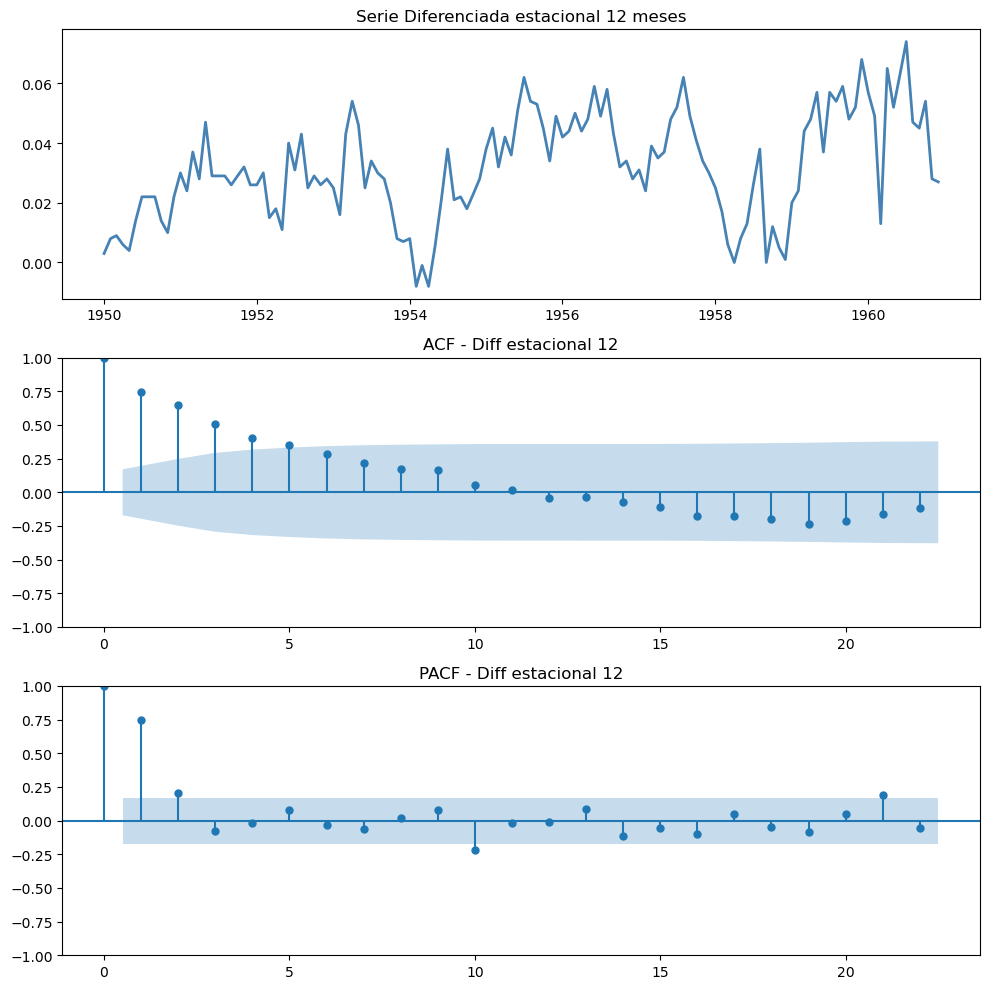

In [18]:
# 10. Diferencia estacional de 12 meses
# Se calcula la diferencia entre cada valor de la serie y el valor de hace 12 meses.
# Esto sirve para eliminar patrones estacionales anuales.
diff_s12_serie_airpassengers = serie_airpassengers.diff(12).dropna()

# 11. Graficar serie diferenciada + ACF + PACF
# Se crea una figura con 3 filas y 1 columna de subgráficos.
# El tamaño total de la figura será de 10 x 10 pulgadas.
fig, axes = plt.subplots(3, 1, figsize=(10, 10))

# Primer gráfico: serie diferenciada estacionalmente.
# Se usa el índice de la serie en el eje X y los valores diferenciados en el eje Y.
axes[0].plot(
    diff_s12_serie_airpassengers.index,
    diff_s12_serie_airpassengers,
    color='steelblue',
    linewidth=2
)

# Se agrega un título al primer gráfico.
axes[0].set_title('Serie Diferenciada estacional 12 meses')

# Segundo gráfico: función de autocorrelación (ACF).
# Muestra la correlación de la serie con sus rezagos.
plot_acf(
    diff_s12_serie_airpassengers,
    ax=axes[1],
    title='ACF - Diff estacional 12'
)

# Tercer gráfico: función de autocorrelación parcial (PACF).
# Muestra la relación directa con cada rezago, eliminando el efecto de los rezagos intermedios.
plot_pacf(
    diff_s12_serie_airpassengers,
    ax=axes[2],
    title='PACF - Diff estacional 12'
)

# Ajusta automáticamente los espacios entre subgráficos
# para que no se encimen los títulos ni las etiquetas.
plt.tight_layout()

# Muestra la figura en pantalla.
plt.show()

📉 Eliminación de la Estacionalidad: La gráfica superior muestra la serie tras aplicar una diferencia estacional ($D=1, s=12$). Al restar el valor actual menos el del mismo mes del año anterior, se ha eliminado el patrón cíclico "perfecto", dejando una serie que, aunque aún tiene tendencia, es más manejable.
🔗 Análisis de la ACF (Autocorrelation Function): En la segunda gráfica, las barras azules que sobresalen de la zona sombreada indican una autocorrelación significativa. El descenso lento y gradual sugiere que la serie aún no es totalmente estacionaria (probablemente necesite una diferencia simple adicional, $d=1$) y que existe una fuerte memoria de corto plazo.
✂️ Análisis de la PACF (Partial Autocorrelation Function): La tercera gráfica muestra la correlación directa entre un punto y sus rezagos, eliminando las influencias intermedias. El hecho de que solo el primer rezago ($lag 1$) sea muy alto y los demás caigan abruptamente dentro del área de confianza es una señal clásica de un componente Autorregresivo (AR 1).
🛡️ Bandas de Confianza: La región sombreada en azul representa el umbral de significancia estadística. Cualquier barra que no supere ese límite se considera "ruido blanco" o insignificante, lo que te ayuda a decidir cuántos términos incluir en tu modelo final para no sobreajustarlo.

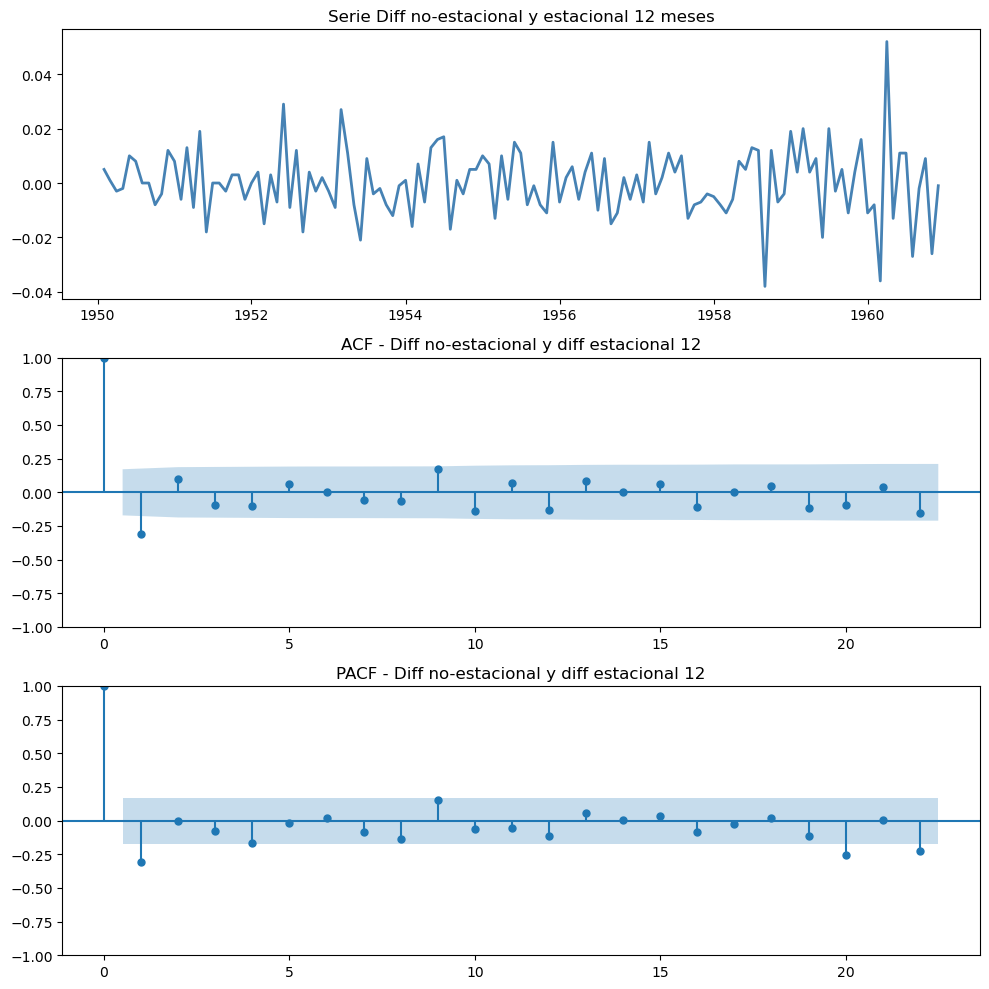

In [19]:
# 12. Diferencia no-estacional sobre la diferencia estacional
# Primero toma la serie que ya estaba diferenciada estacionalmente (de 12 meses)
# y ahora le aplica una diferencia simple entre observaciones consecutivas.
# Esto ayuda a eliminar también la tendencia además de la estacionalidad.
ddiff_s12_serie_airpassengers = diff_s12_serie_airpassengers.diff().dropna()

# 13. Graficar serie doblemente diferenciada + ACF + PACF
# Se crea una figura con 3 subgráficos verticales.
# El tamaño de la figura será de 10 x 10 pulgadas.
fig, axes = plt.subplots(3, 1, figsize=(10, 10))

# Primer gráfico: serie con doble diferenciación.
# Se muestra la evolución temporal de la serie ya transformada.
axes[0].plot(
    ddiff_s12_serie_airpassengers.index,
    ddiff_s12_serie_airpassengers,
    color='steelblue',
    linewidth=2
)

# Título del primer gráfico.
axes[0].set_title('Serie Diff no-estacional y estacional 12 meses')

# Segundo gráfico: ACF de la serie doblemente diferenciada.
# Permite ver si aún existe autocorrelación en distintos rezagos.
plot_acf(
    ddiff_s12_serie_airpassengers,
    ax=axes[1],
    title='ACF - Diff no-estacional y diff estacional 12'
)

# Tercer gráfico: PACF de la serie doblemente diferenciada.
# Sirve para identificar la relación directa con los rezagos.
plot_pacf(
    ddiff_s12_serie_airpassengers,
    ax=axes[2],
    title='PACF - Diff no-estacional y diff estacional 12'
)

# Ajusta los espacios entre los subgráficos para que se vean ordenados.
plt.tight_layout()

# Muestra la figura final.
plt.show()

⚪ Estacionariedad Completa: La serie superior ya no tiene tendencia ni ciclos. Estadísticamente, esto significa que la media y la varianza son constantes en el tiempo. Has transformado datos complejos en lo que se conoce como Ruido Blanco, el estado ideal para validar que has extraído toda la información predecible.
📉 Identificación del modelo (Corte de ACF): En la segunda gráfica, la ACF muestra un "corte" abrupto después del primer rezago. Esto sugiere que el proceso tiene un componente de Media Móvil (MA), lo que indica que el valor actual depende del error del periodo anterior.

🔍 Correlación Negativa en Lag 1: Tanto en la ACF como en la PACF, el primer rezago es significativamente negativo. Esto es común tras una sobre-diferenciación o cuando existe un efecto de "corrección" inmediata: si un valor fue muy alto el mes pasado (tras quitar la tendencia), este mes tiende a ser más bajo.

✅ Validación de Residuos: El hecho de que casi todos los demás rezagos estén dentro de la franja azul (intervalo de confianza del 95%) confirma que no queda estructura sistemática por explicar. Tu modelo ha capturado la "señal" y lo que queda en la gráfica es puramente azar estadístico.

In [20]:
# 14. Función de prueba de estacionariedad
def test_estacionariedad(datos):
    # Se aplica la prueba Augmented Dickey-Fuller (ADF).
    # Esta prueba evalúa si la serie tiene raíz unitaria.
    # Hipótesis nula: la serie no es estacionaria.
    adf_result = adfuller(datos)

    # Se aplica la prueba KPSS.
    # Esta prueba evalúa lo contrario: si la serie es estacionaria alrededor de una media constante.
    # Hipótesis nula: la serie es estacionaria.
    kpss_result = kpss(datos, regression='c')

    # Se crea una tabla con los resultados de ambas pruebas.
    tab_test = pd.DataFrame({
        'Test'        : ["Prueba Augmented Dickey-Fuller (ADF)", "Prueba KPSS"],
        'Estadístico' : [round(adf_result[0], 4), round(kpss_result[0], 4)],
        'P-valor'     : [round(adf_result[1], 4), round(kpss_result[1], 4)],
        'Estacionario': [
            "Sí" if adf_result[1] < 0.05 else "No",
            "No" if kpss_result[1] < 0.05 else "Sí"
        ]
    })

    # Imprime una línea separadora.
    print("=" * 80)

    # Imprime el título del bloque de resultados.
    print("PRUEBA DE ESTACIONARIEDAD")

    # Imprime otra línea separadora.
    print("=" * 80)

    # Muestra la tabla con los resultados de ADF y KPSS.
    print(tab_test)

    # Imprime una última línea separadora.
    print("=" * 80)


# 15. Aplicar prueba sobre la serie doblemente diferenciada
# Se ejecuta la función anterior sobre la serie ya diferenciada en forma estacional y no estacional.
test_estacionariedad(ddiff_s12_serie_airpassengers)

PRUEBA DE ESTACIONARIEDAD
                                   Test  Estadístico  P-valor Estacionario
0  Prueba Augmented Dickey-Fuller (ADF)     -15.5956      0.0           Sí
1                           Prueba KPSS       0.0468      0.1           Sí


🎯 Rechazo de la No Estacionariedad (ADF): En la prueba Augmented Dickey-Fuller, el P-valor de $0.0$ (menor a $0.05$) permite rechazar la hipótesis nula ($H_0$) de que existe una raíz unitaria. Esto confirma estadísticamente que la serie ha dejado de tener una tendencia y es estacionaria en media.✅ No Rechazo de la Estacionariedad (KPSS): A diferencia de la ADF, en la prueba KPSS la hipótesis nula es que la serie es estacionaria. Un P-valor de $0.1$ (mayor a $0.05$) significa que no hay evidencia suficiente para rechazar $H_0$. Ambas pruebas coinciden, lo que da una robustez total al análisis.
🔄 Consistencia de Resultados: Cuando el test ADF es significativo (P-valor bajo) y el KPSS no es significativo (P-valor alto), se llega a la conclusión de que la serie es estacionaria pura. Esto te da "luz verde" para proceder con la estimación de parámetros del modelo SARIMA sin riesgo de regresiones espurias.
📉 Estabilidad de la Varianza: El valor tan bajo del estadístico KPSS ($0.0468$) sugiere que, tras las diferencias aplicadas, la varianza se mantiene muy estable a lo largo del tiempo, cumpliendo con los supuestos de homogeneidad necesarios para pronósticos confiables.

In [21]:
# 16. Estimar modelos SARIMA manualmente
# Se ajusta un modelo SARIMA con orden no estacional (0,1,2)
# y orden estacional (0,1,1) con periodicidad 12 meses.
# Esto significa:
# p=0, d=1, q=2  -> parte no estacional
# P=0, D=1, Q=1, m=12 -> parte estacional anual
arima012011 = ARIMA(
    serie_airpassengers,
    order=(0, 1, 2),
    seasonal_order=(0, 1, 1, 12)
).fit()

# Se ajusta otro modelo SARIMA manual con orden no estacional (2,1,0)
# y la misma parte estacional (0,1,1,12).
arima210011 = ARIMA(
    serie_airpassengers,
    order=(2, 1, 0),
    seasonal_order=(0, 1, 1, 12)
).fit()


# 17. Búsqueda exhaustiva con auto_arima
# auto_arima prueba múltiples combinaciones de parámetros para encontrar
# el mejor modelo según el criterio AIC.
m_autoarima = auto_arima(
    serie_airpassengers,      # serie de tiempo original
    seasonal=True,            # indica que sí hay componente estacional
    m=12,                     # periodicidad estacional de 12 meses
    stepwise=False,           # desactiva búsqueda paso a paso; hace búsqueda más exhaustiva
    approximation=False,      # usa cálculo exacto en lugar de aproximaciones
    information_criterion='aic',  # criterio para elegir el mejor modelo
    trace=True                # imprime el progreso de la búsqueda
)

# Con los órdenes encontrados por auto_arima, se ajusta un modelo ARIMA/SARIMA final.
auto_sarima = ARIMA(
    serie_airpassengers,
    order=m_autoarima.order,
    seasonal_order=m_autoarima.seasonal_order
).fit()


# 18. Imprimir órdenes seleccionados por auto_arima
# Se imprimen los valores elegidos automáticamente por el algoritmo.
print("=" * 80)
print(f"Orden seleccionado por AutoARIMA: {m_autoarima.order}")
print(f"Orden estacional seleccionado:    {m_autoarima.seasonal_order}")
print("=" * 80)


# 19. Guardar modelos en diccionario
# Se almacenan los modelos entrenados con un nombre descriptivo.
# Esto facilita compararlos o usarlos después para predicción.
list_modelos = {
    "ARIMA(0,1,2)(0,1,1)12" : arima012011,
    "ARIMA(2,1,0)(0,1,1)12" : arima210011,
    "AutoSARIMA"           : auto_sarima
}

# Se muestra un mensaje indicando qué modelos ya fueron entrenados.
print("Modelos entrenados:")
for nombre in list_modelos:
    print(f"  ✔ {nombre}")

 ARIMA(0,1,0)(0,1,0)[12]             : AIC=-778.324, Time=0.07 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=-778.953, Time=0.24 sec
 ARIMA(0,1,0)(0,1,2)[12]             : AIC=-777.555, Time=0.81 sec
 ARIMA(0,1,0)(1,1,0)[12]             : AIC=-779.394, Time=0.15 sec
 ARIMA(0,1,0)(1,1,1)[12]             : AIC=-777.032, Time=0.77 sec
 ARIMA(0,1,0)(1,1,2)[12]             : AIC=-775.583, Time=1.01 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=-777.701, Time=0.63 sec
 ARIMA(0,1,0)(2,1,1)[12]             : AIC=-775.685, Time=1.04 sec
 ARIMA(0,1,0)(2,1,2)[12]             : AIC=-773.383, Time=1.50 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=-789.186, Time=0.19 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=-788.821, Time=0.34 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=-790.279, Time=0.56 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=-789.406, Time=0.32 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=-789.407, Time=0.89 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=-788.322, Time=1.20

In [ ]:
# 20. Función para comparar modelos por criterios de información y métricas
def comparar_modelos_arima(modelos: dict) -> pd.DataFrame:
    # Crea un DataFrame comparando todos los modelos en el diccionario.
    # Extrae métricas de cada modelo entrenado automáticamente.
    df_modelos = (
        pd.DataFrame({
            "Modelo"  : list(modelos),                           # Nombres de los modelos
            "AIC"     : [m.aic       for m in modelos.values()],  # Criterio de información AIC
            "AICc"    : [m.aicc      for m in modelos.values()],  # AIC corregido (mejor para muestras pequeñas)
            "BIC"     : [m.bic       for m in modelos.values()],  # Criterio de información BIC
            "Log-Lik" : [m.llf       for m in modelos.values()],  # Log-verosimilitud
            "MSE"     : [m.mse       for m in modelos.values()],  # Error cuadrático medio
            "RMSE"    : [m.mse**0.5  for m in modelos.values()],  # Raíz del error cuadrático medio
            "MAE"     : [m.mae       for m in modelos.values()],  # Error absoluto medio
            "Params"  : [m.df_model  for m in modelos.values()],  # Número de parámetros del modelo
            "Obs"     : [m.nobs      for m in modelos.values()],  # Número de observaciones
        })
        # Ordena los modelos de menor a mayor AICc (el mejor primero)
        .sort_values("AICc")
        # Agrega una columna de ranking (1 = mejor modelo)
        .assign(Ranking=lambda df: range(1, len(df) + 1))
        # Establece el ranking como índice de la tabla
        .set_index("Ranking")
    )

    # Identifica el mejor modelo (el que tiene menor AICc)
    mejor      = df_modelos.iloc[0]["Modelo"]
    mejor_aicc = df_modelos.iloc[0]["AICc"]

    # Imprime resultados con formato profesional
    print("=" * 100)
    print("COMPARACIÓN DE MODELOS ARIMA")
    print("=" * 100)
    print(df_modelos.to_string())  # Muestra la tabla completa
    print("-" * 100)
    print(f"Mejor modelo (menor AICc): {mejor}  →  AICc: {mejor_aicc}")
    print("=" * 100)

    # Retorna la tabla para poder usarla después si es necesario
    return df_modelos


# 21. Comparar los modelos entrenados
# Aplica la función anterior al diccionario de modelos entrenados.
# Esto mostrará una tabla ordenada con el mejor modelo en la posición #1.
comparar_modelos_arima(list_modelos)

COMPARACIÓN DE MODELOS ARIMA
                        Modelo         AIC        AICc         BIC     Log-Lik       MSE      RMSE       MAE  Params  Obs
Ranking                                                                                                                  
1                   AutoSARIMA -792.134532 -791.457113 -774.883348  402.067266  0.000236  0.015366  0.009995       6  144
2        ARIMA(2,1,0)(0,1,1)12 -786.924021 -786.606561 -775.423232  397.462011  0.000245  0.015654  0.010092       4  144
3        ARIMA(0,1,2)(0,1,1)12 -786.818915 -786.501455 -775.318126  397.409458  0.000245  0.015657  0.010153       4  144
----------------------------------------------------------------------------------------------------
Mejor modelo (menor AICc): AutoSARIMA  →  AICc: -791.4571125287266


,Modelo,AIC,AICc,BIC,Log-Lik,MSE,RMSE,MAE,Params,Obs
Ranking,,,,,,,,,,
1,AutoSARIMA,-792.134532,-791.457113,-774.883348,402.067266,0.000236,0.015366,0.009995,6,144
2,"ARIMA(2,1,0)(0,1,1)12",-786.924021,-786.606561,-775.423232,397.462011,0.000245,0.015654,0.010092,4,144
3,"ARIMA(0,1,2)(0,1,1)12",-786.818915,-786.501455,-775.318126,397.409458,0.000245,0.015657,0.010153,4,144


In [14]:
# 22. Reporte detallado del mejor modelo
mejor_modelo = list_modelos['AutoSARIMA']
print(mejor_modelo.summary())

                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                  144
Model:             ARIMA(1, 1, 4)x(0, 1, [], 12)   Log Likelihood                 402.067
Date:                           Sat, 11 Apr 2026   AIC                           -792.135
Time:                                   10:30:57   BIC                           -774.883
Sample:                               01-01-1949   HQIC                          -785.125
                                    - 12-01-1960                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8151      0.121     -6.709      0.000      -1.053      -0.577
ma.L1          0.4980      0.143      3.477

🎯 Significancia de Parámetros (P>|z|): Los coeficientes ar.L1, ma.L1, ma.L2 y ma.L4 tienen p-valores menores a 0.05, lo que significa que son estadísticamente significativos para el modelo. Sin embargo, el componente ma.L3 tiene un p-valor de 0.325, lo que sugiere que podrías intentar simplificar el modelo eliminando ese rezago sin perder calidad.
📉 Criterios de Información (AIC/BIC): Los valores de AIC (-792.1) y BIC (-774.8) son muy bajos (negativos y alejados de cero). En la selección de modelos, entre más bajo sea este valor, mejor es el equilibrio entre la precisión del ajuste y la simplicidad del modelo (evitando el sobreajuste).
⚖️ Independencia de Residuos (Ljung-Box): El Prob(Q) de 0.78 es excelente. Al ser mayor a $0.05$, no podemos rechazar la hipótesis nula, lo que significa que los residuos son independientes y se comportan como ruido blanco. No queda información "atrapada" en los errores.
🔔 Normalidad (Jarque-Bera): El Prob(JB) de 0.09 está justo por encima del umbral de $0.05$. Esto indica que los residuos siguen una distribución aproximadamente normal, cumpliendo con uno de los supuestos más importantes para que los intervalos de confianza de tus predicciones sean válidos.
⚠️ Heterocedasticidad (H): El p-valor de 0.00 en la prueba de Heterocedasticidad indica que la varianza de los residuos no es totalmente constante a lo largo del tiempo. Esto es común en datos financieros o de pasajeros, y refuerza que la transformación inicial que hiciste era necesaria.

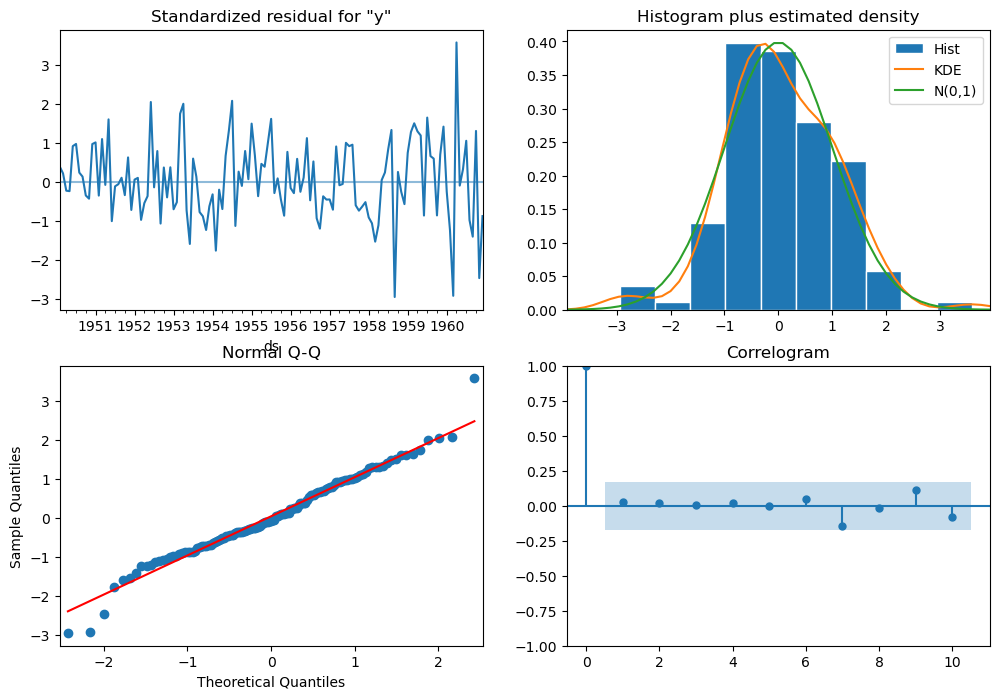

In [15]:
# 23. Diagnóstico visual del mejor modelo (verificación de ruido blanco)
mejor_modelo.plot_diagnostics(figsize=(12, 8))
plt.show()

📉 Residuos Estandarizados: Los errores fluctúan alrededor de cero sin mostrar patrones obvios (como ondas o tendencias). Esto indica que el modelo ha extraído la estructura principal de los datos, aunque se observa un aumento de volatilidad hacia 1960, lo que confirma la heterocedasticidad detectada previamente.
🔔 Histograma y Densidad (KDE): La curva naranja (KDE) sigue de cerca a la curva verde (distribución normal teórica $N(0,1)$). Estadísticamente, esto valida que los errores del modelo se distribuyen de forma normal, un requisito clave para que tus predicciones futuras sean confiables.
📍 Gráfico Q-Q Normal: Casi todos los puntos azules se alinean sobre la línea roja de 45 grados. Esto es una prueba visual de normalidad; las desviaciones en los extremos (colas) son mínimas, lo que sugiere que no hay valores atípicos (outliers) extremos que estén distorsionando el modelo.🔗 Correlograma de Residuos: En la gráfica de autocorrelación (ACF), todas las barras (excepto el lag 0) se mantienen dentro de la franja azul sombreada. Esto confirma que los residuos son independientes (ruido blanco) y que no queda información temporal sin explicar.

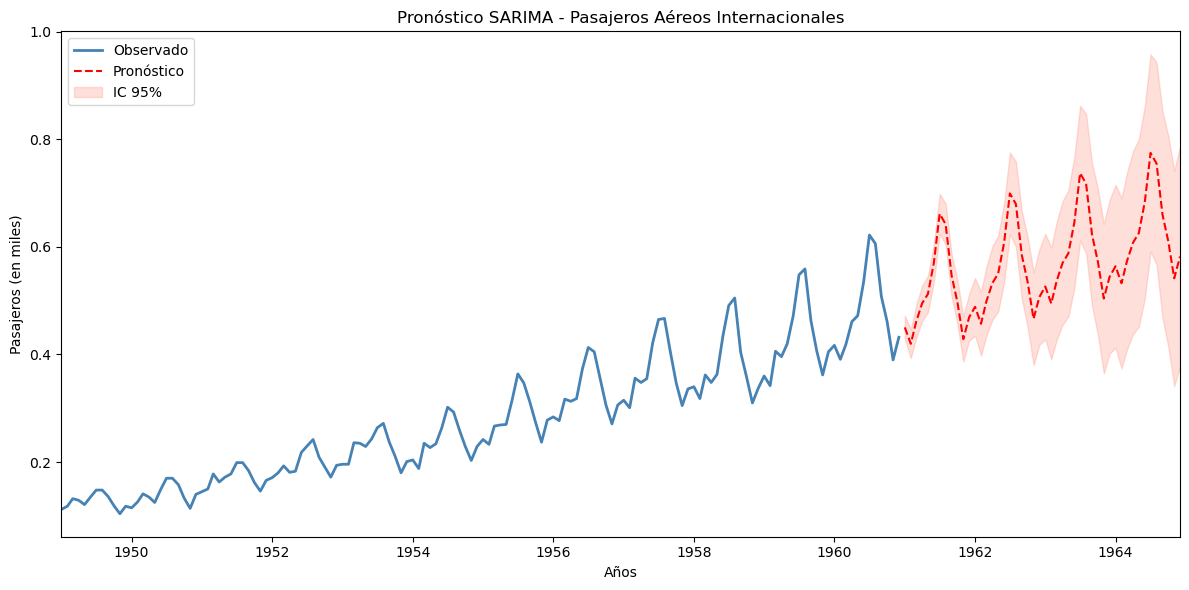

            Pronóstico  IC Inferior  IC Superior
Fecha                                           
1961-01-01       0.450        0.429        0.472
1961-02-01       0.420        0.393        0.446
1961-03-01       0.461        0.431        0.491
1961-04-01       0.495        0.462        0.528
1961-05-01       0.512        0.479        0.546
1961-06-01       0.570        0.535        0.606
1961-07-01       0.662        0.625        0.698
1961-08-01       0.642        0.604        0.681
1961-09-01       0.547        0.507        0.586
1961-10-01       0.498        0.457        0.539
1961-11-01       0.428        0.386        0.471
1961-12-01       0.469        0.426        0.512
1962-01-01       0.489        0.435        0.542
1962-02-01       0.457        0.398        0.516
1962-03-01       0.499        0.435        0.563
1962-04-01       0.533        0.464        0.601
1962-05-01       0.550        0.480        0.621
1962-06-01       0.608        0.534        0.682
1962-07-01       0.6

In [17]:
# 24. Pronóstico de los próximos 4 años (48 meses)
t_pronostico    = 48
ultimo_dato     = serie_airpassengers.index[-1]
anio_pronostico = pd.date_range(start=ultimo_dato + pd.offsets.MonthBegin(1), periods=t_pronostico, freq='MS')

# 25. Obtener valores medios e intervalos de confianza
pronostico = mejor_modelo.get_forecast(steps=t_pronostico)
pred_mean  = pronostico.predicted_mean
pred_ci    = pronostico.conf_int()

# 26. Alinear índice con fechas reales del pronóstico
pred_mean.index = anio_pronostico
pred_ci.index   = anio_pronostico

# 27. Graficar serie observada + pronóstico + intervalo de confianza
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(serie_airpassengers.index, serie_airpassengers, label="Observado", color='steelblue', linewidth=2)
ax.plot(pred_mean.index, pred_mean, label="Pronóstico", color='red', linestyle='--')
ax.fill_between(
    pred_ci.index,
    pred_ci.iloc[:, 0],
    pred_ci.iloc[:, 1],
    color='tomato', alpha=.2, label="IC 95%"
)
ax.set_xlim(pd.Timestamp('1949-01-01'), anio_pronostico[-1])
ax.set_xlabel('Años')
ax.set_ylabel('Pasajeros (en miles)')
ax.set_title('Pronóstico SARIMA - Pasajeros Aéreos Internacionales')
ax.legend()
plt.tight_layout()
plt.show()

# 28. Tabla de pronóstico
df_forecast = pd.DataFrame({
    "Pronóstico"  : pred_mean.round(3),
    "IC Inferior" : pred_ci.iloc[:, 0].round(3),
    "IC Superior" : pred_ci.iloc[:, 1].round(3)
})
df_forecast.index.name = "Fecha"
print(df_forecast)